In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,AC,Washing Machine,Dining Table,Microwave,Wardrobe,Bed,Modular Kitchen,Water Purifier,Exhaust Fan,Fan,Chimney,Stove,Sofa,Fridge,Light,Curtains,TV,Geyser,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,5,0,0,0,3,0,1,0,1,6,1,0,0,0,15,4,0,3,2,174


### property_type vs price

<Axes: xlabel='property_type', ylabel='price'>

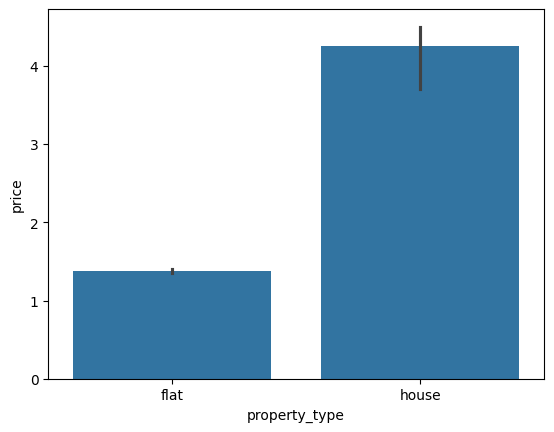

In [5]:
sns.barplot(x=df['property_type'],y=df['price'], estimator=np.median)

<Axes: xlabel='property_type', ylabel='price'>

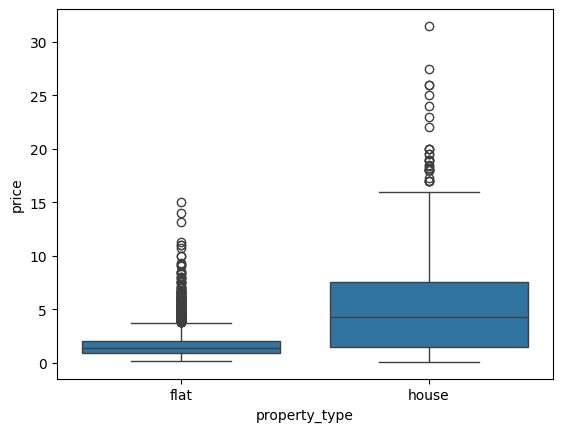

In [6]:
sns.boxplot(x=df['property_type'], y=df['price'])

### property_type vs area

<Axes: xlabel='property_type', ylabel='area'>

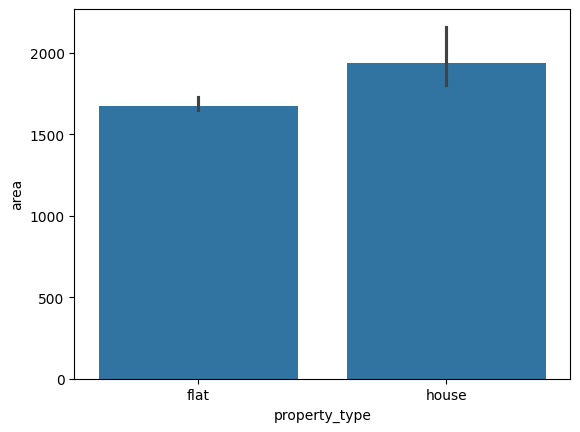

In [7]:
sns.barplot(x=df['property_type'],y=df['area'],estimator=np.median)

<Axes: xlabel='property_type', ylabel='built_up_area'>

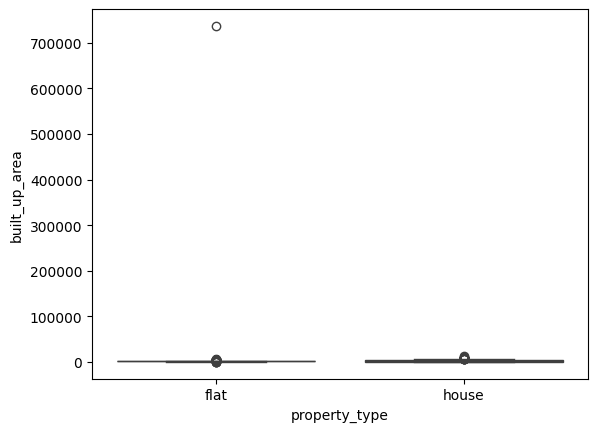

In [8]:
sns.boxplot(x=df['property_type'], y=df['built_up_area'])

<Axes: xlabel='property_type', ylabel='built_up_area'>

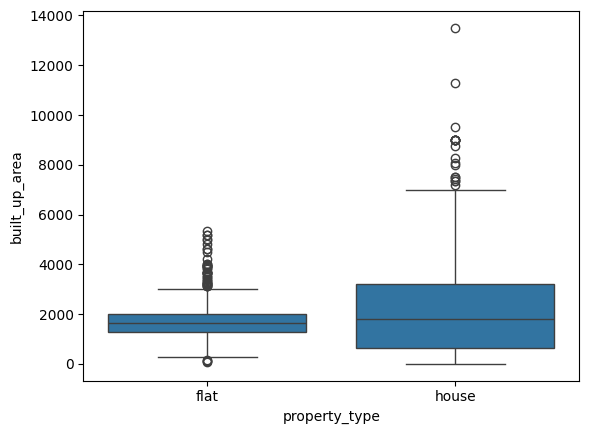

In [9]:
# removing that crazy outlier
df = df[df['built_up_area'] != 737147]

sns.boxplot(x=df['property_type'], y=df['built_up_area'])

### property_type vs price_per_sqft

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

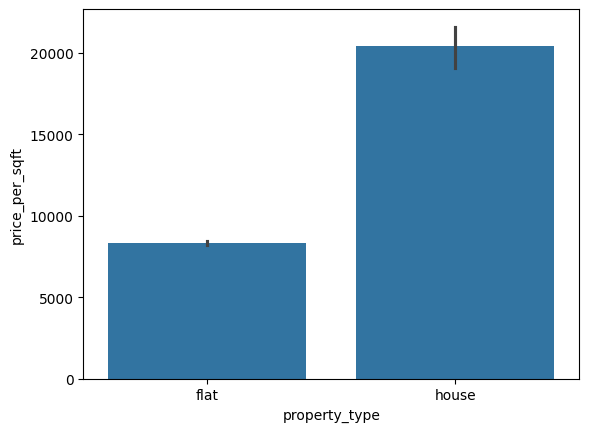

In [10]:
sns.barplot(x=df['property_type'],y=df['price_per_sqft'],estimator=np.median)

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

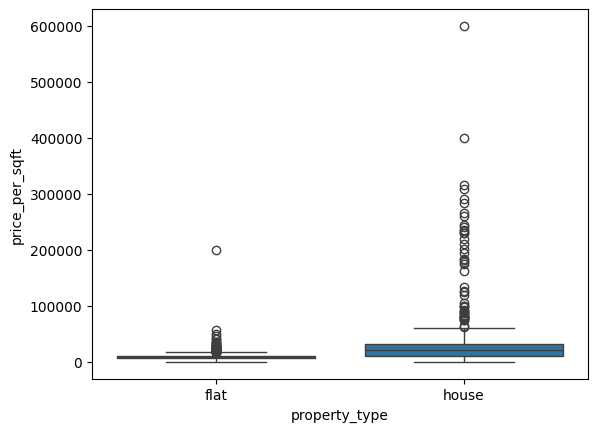

In [11]:
sns.boxplot(x=df['property_type'], y=df['price_per_sqft'])

In [12]:
# checking the outliers in the price_per_sqft column
df[df['price_per_sqft'] > 100000][['property_type','society','sector','price','price_per_sqft','area','areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,super_built_up_area,built_up_area,carpet_area
229,house,rk excelo,sector 12,0.60,120000.0,50.0,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,NaN,30.0,15.0
336,house,independent,sector 28,4.50,125000.0,360.0,Built Up area: 360 (33.45 sq.m.),NaN,360.0,NaN
342,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),NaN,240.0,NaN
545,house,independent,sector 24,10.00,229885.0,435.0,Carpet area: 435 (40.41 sq.m.),NaN,NaN,435.0
867,house,ardee city,sector 52,5.50,183333.0,300.0,Plot area 300(27.87 sq.m.),NaN,300.0,NaN
975,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),NaN,232.0,NaN
1027,house,dlf the grove,sector 54,5.70,211111.0,270.0,Built Up area: 270 (25.08 sq.m.),NaN,270.0,NaN
1062,house,independent,sector 23,2.80,161849.0,173.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,NaN,160.0,150.0
1259,house,vipul tatvam villa,sector 48,7.25,201388.0,360.0,Plot area 360(33.45 sq.m.),NaN,360.0,NaN
1385,house,unitech uniworld resorts,sector 33,9.50,173992.0,546.0,Plot area 546(50.73 sq.m.),NaN,546.0,NaN


I see, there is a data error in these rows. The area calculation is wrong, that is why price_per_sqft is shown so high. I won't delete these outliers, I'll rather fix them later.

In [13]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,AC,Washing Machine,Dining Table,Microwave,Wardrobe,Bed,Modular Kitchen,Water Purifier,Exhaust Fan,Fan,Chimney,Stove,Sofa,Fridge,Light,Curtains,TV,Geyser,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,5,0,0,0,3,0,1,0,1,6,1,0,0,0,15,4,0,3,2,174


<Axes: xlabel='bedRoom', ylabel='property_type'>

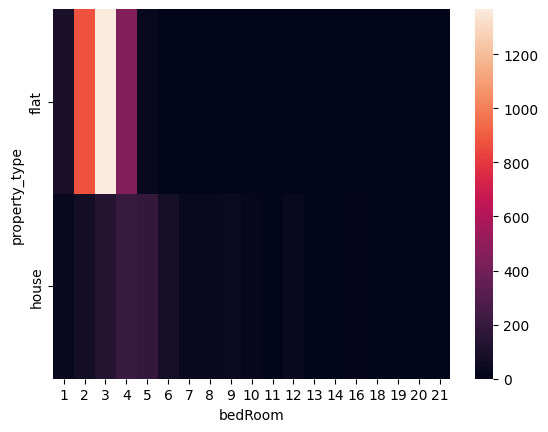

In [14]:
sns.heatmap(pd.crosstab(df['property_type'],df['bedRoom']))

In [15]:
df[df['bedRoom']>=10]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,AC,Washing Machine,Dining Table,Microwave,Wardrobe,Bed,Modular Kitchen,Water Purifier,Exhaust Fan,Fan,Chimney,Stove,Sofa,Fridge,Light,Curtains,TV,Geyser,furnishing_type,luxury_score
19,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,18,1,0,1,36,36,1,1,1,22,1,0,0,1,40,0,18,18,0,70
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,0,0,0,2,0,0,0,0,1,0,0,0,0,1,0,0,0,1,7
66,house,independent,sector 13,0.50,90909.0,55.0,Plot area 55(5.11 sq.m.),12,4,3,4.0,NaN,Old Property,NaN,55.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,15
78,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,68
119,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,Relatively New,NaN,2700.0,NaN,1,1,0,1,0,0,0,0,0,9,0,1,0,1,8,1,1,0,0,11,0,0,9,2,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,house,independent,sector 25,NaN,NaN,NaN,Plot area 250(209.03 sq.m.)Built Up area: 260 ...,12,12,3+,4.0,North-East,New Property,NaN,260.0,245.0,1,1,0,1,1,12,0,0,4,12,0,1,1,1,12,4,1,0,0,75,12,0,12,0,144
3519,house,huda plot sector 38,sector 38,4.30,245398.0,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,5.0,North-West,Relatively New,NaN,145.0,NaN,0,0,0,0,0,12,1,0,0,16,0,1,1,1,17,0,0,1,1,52,0,13,13,0,7
3618,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,0,1,1,1,21,21,1,1,1,21,1,1,1,1,21,1,0,21,0,49
3698,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,0,0,0,0,8,0,1,0,1,9,1,1,0,0,16,0,0,3,2,49


~ There is some data error in these outliers. i.e. In a row, it shows 12 bedrooms but area is only 150. 

In [16]:
df.groupby('property_type')['floorNum'].max()

property_type
flat     45.0
house    51.0
Name: floorNum, dtype: float64

<Axes: xlabel='property_type', ylabel='floorNum'>

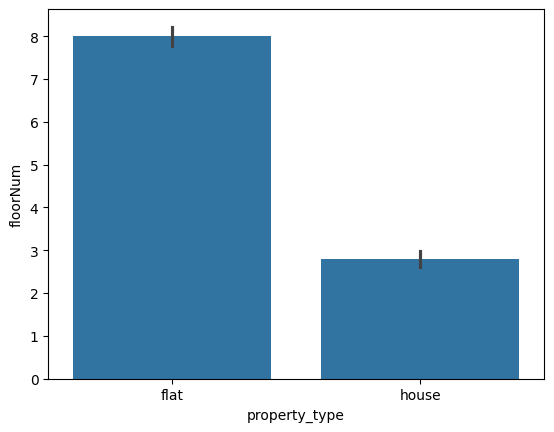

In [17]:
sns.barplot(x=df['property_type'],y=df['floorNum'])

<Axes: xlabel='property_type', ylabel='floorNum'>

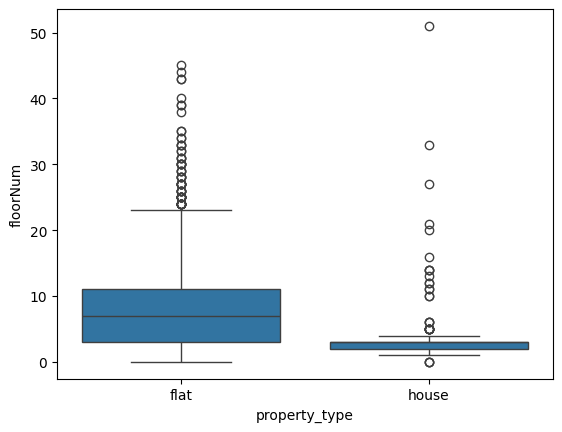

In [18]:
sns.boxplot(x=df['property_type'],y=df['floorNum'])

In [19]:
# checking for outliers
df[(df['property_type'] == 'house') & (df['floorNum'] > 10)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,AC,Washing Machine,Dining Table,Microwave,Wardrobe,Bed,Modular Kitchen,Water Purifier,Exhaust Fan,Fan,Chimney,Stove,Sofa,Fridge,Light,Curtains,TV,Geyser,furnishing_type,luxury_score
35,house,greenopolis,sector 89,0.70,5397.0,1297.0,Built Up area: 1297 (120.5 sq.m.),2,2,2,14.0,North-East,Undefined,NaN,1297.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
106,house,suncity avenue 76,sector 76,0.75,10067.0,745.0,Plot area 745(69.21 sq.m.)Built Up area: 745 s...,2,2,2,11.0,North-East,New Property,NaN,745.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,40
267,house,ninex city,sector 76,1.75,6250.0,2800.0,Carpet area: 2800 (260.13 sq.m.),4,4,0,14.0,NaN,Undefined,NaN,NaN,2800.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
338,house,spaze privy,sector 72,3.09,6981.0,4426.0,Built Up area: 3653 (339.37 sq.m.)Carpet area:...,5,5,3+,14.0,East,Relatively New,NaN,3653.0,2922.0,0,1,0,0,0,8,0,0,0,5,0,0,1,0,9,0,0,0,0,1,0,0,1,2,33
420,house,spaze privy,sector 72,3.10,8486.0,3653.0,Plot area 3653(339.37 sq.m.),5,5,3+,21.0,NaN,Relatively New,NaN,3653.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1297,house,indiabulls centrum park,sector 103,3.25,8125.0,4000.0,Plot area 4000(371.61 sq.m.),4,3,3+,20.0,NaN,Under Construction,NaN,4000.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,51
2147,house,ireo victory valley,sector 67,8.00,22222.0,3600.0,Plot area 400(334.45 sq.m.),6,7,3+,51.0,North-East,Moderately Old,NaN,3600.0,NaN,1,1,0,1,0,9,0,0,0,24,0,1,0,1,15,1,1,0,0,36,0,0,10,2,49
2167,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,9,0,0,0,9,0,1,1,1,9,0,0,0,1,20,0,9,9,0,7
2556,house,dlf the arbour,sector 63,8.50,21519.0,3950.0,Built Up area: 3950 (366.97 sq.m.),4,4,3+,27.0,NaN,Undefined,NaN,3950.0,NaN,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,61
2796,house,independent,sector 92,1.80,7627.0,2360.0,Built Up area: 2360 (219.25 sq.m.),4,5,0,13.0,NaN,Undefined,NaN,2360.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


~ It shocked me to see that there are houses in Gurugram at 21st, 30th and even at 51st floor, But after a little bit of research, I found out that these outliers are actually those kind of houses which are built on top of some apartment. So, basically, they are like Vilaas, airtop houses type of thing. 

<Axes: xlabel='agePossession', ylabel='property_type'>

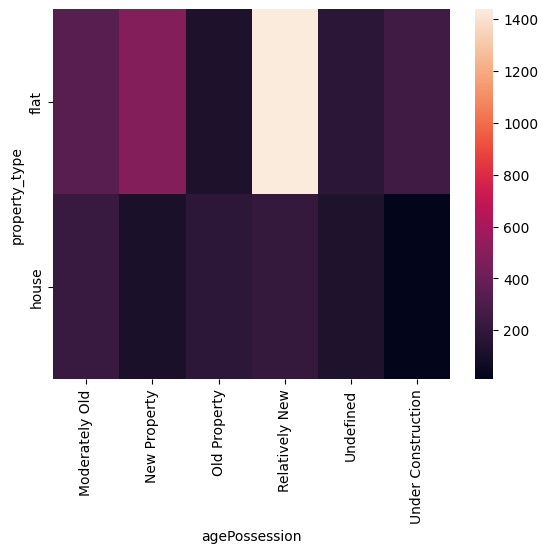

In [20]:
sns.heatmap(pd.crosstab(df['property_type'],df['agePossession']))

<Axes: xlabel='bedRoom', ylabel='property_type'>

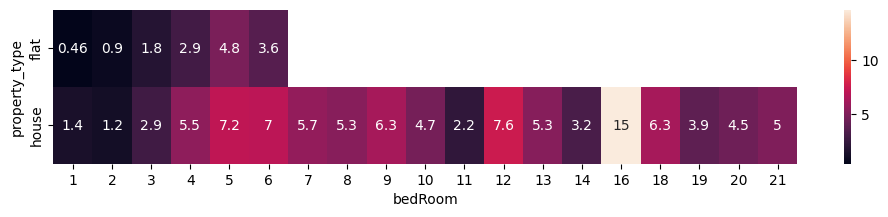

In [21]:
plt.figure(figsize=(12,2))
sns.heatmap(pd.pivot_table(df,index='property_type',columns='bedRoom',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='furnishing_type', ylabel='property_type'>

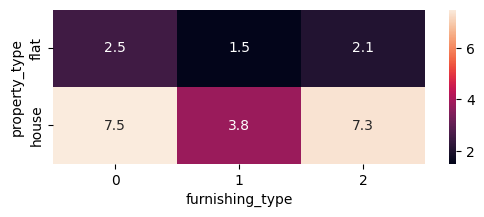

In [22]:
plt.figure(figsize=(6,2))
sns.heatmap(pd.pivot_table(df,index='property_type',columns='furnishing_type',values='price',aggfunc='mean'),annot=True)

By the heatmap, I can say:- 
- 0 : Furnished
- 2 : Semi-Furnished
- 1 : Unfurnished

<Axes: xlabel='property_type', ylabel='luxury_score'>

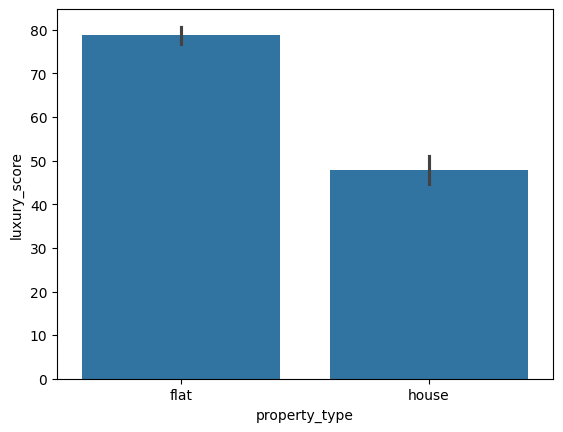

In [23]:
sns.barplot(x=df['property_type'],y=df['luxury_score'])

#### sector analysis

<Axes: xlabel='sector', ylabel='property_type'>

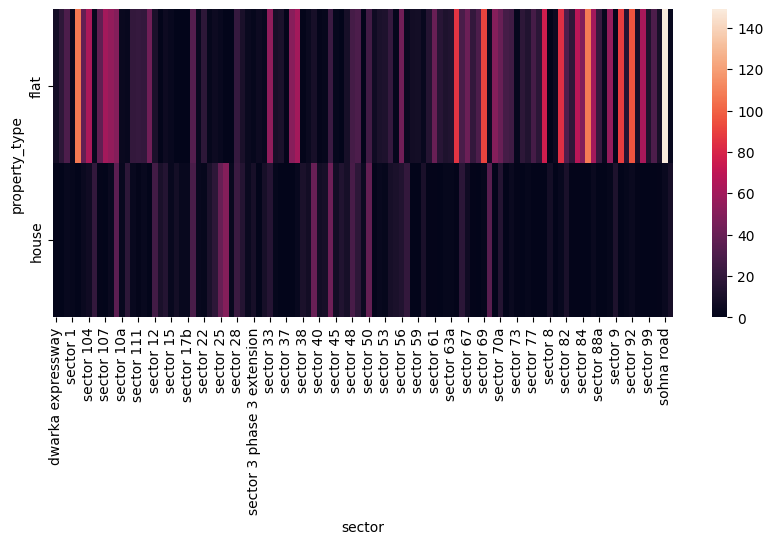

In [24]:
plt.figure(figsize=(10,4))
sns.heatmap(pd.crosstab(df['property_type'],df['sector'].sort_index()))

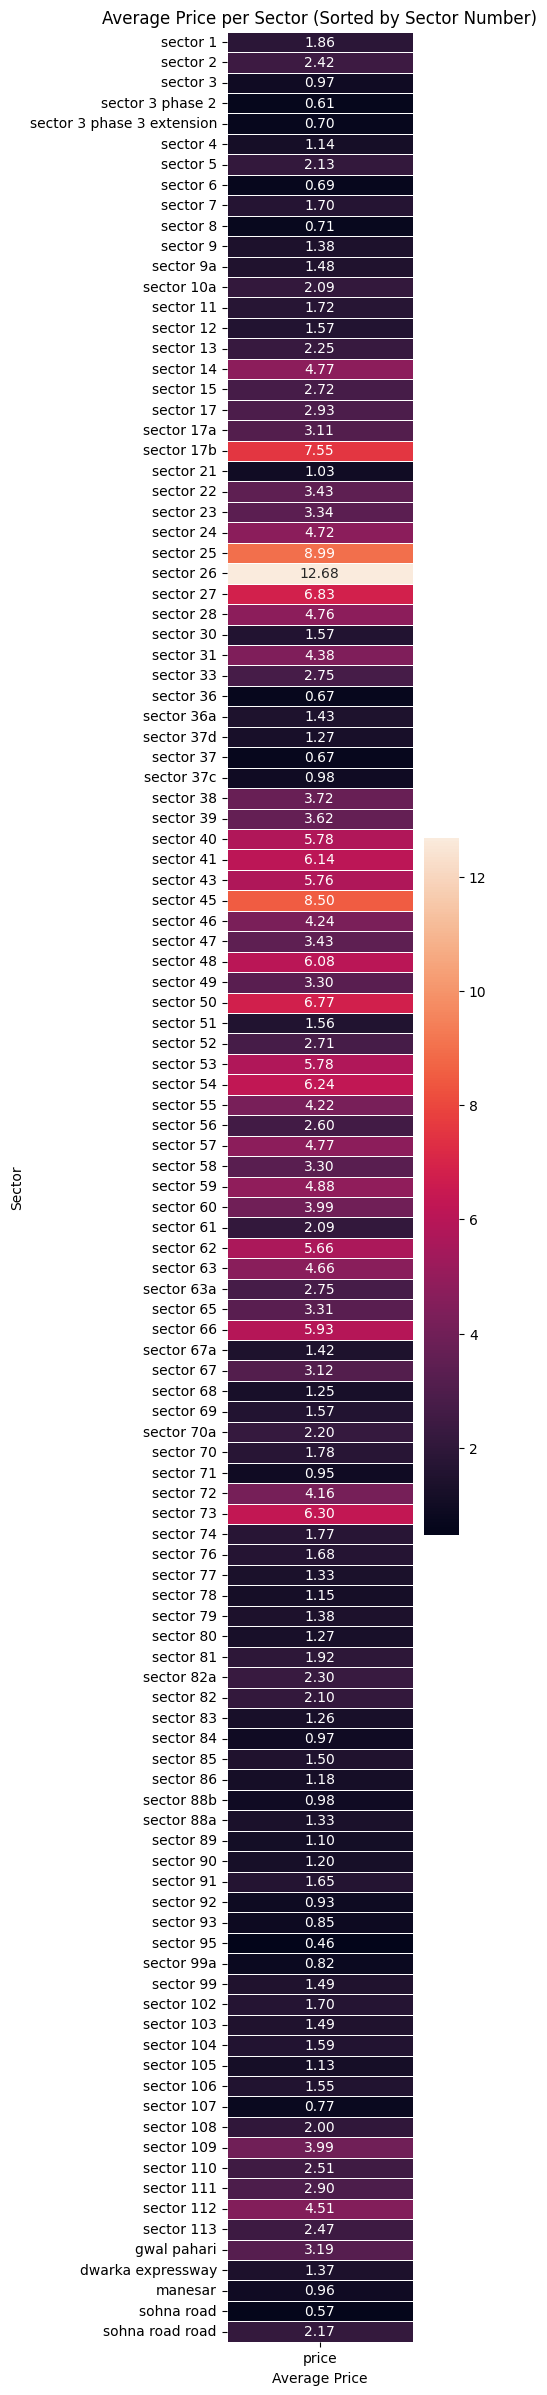

In [25]:
# average price of house/flat in every sector

import re

# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors
        

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(3, 30))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()

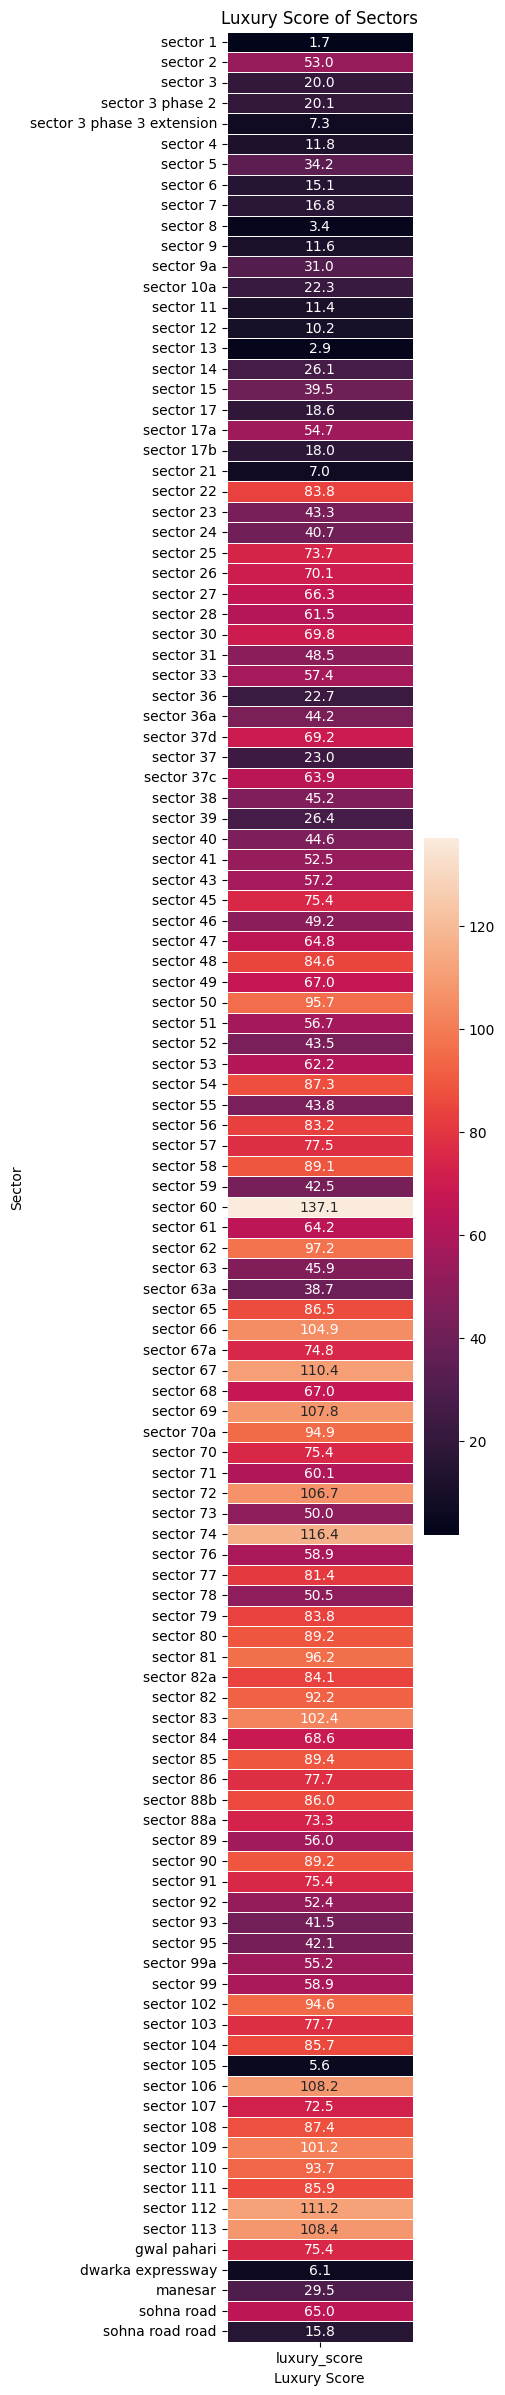

In [26]:
# Luxury score of each sector

sector_luxury_score = df.groupby('sector')['luxury_score'].mean().reset_index()

sector_luxury_score['sector_number'] = sector_luxury_score['sector'].apply(extract_sector_number)

sector_luxury_score_sorted_by_sector = sector_luxury_score.sort_values(by='sector_number')

plt.figure(figsize=(3,30))
sns.heatmap(sector_luxury_score_sorted_by_sector.set_index('sector')[['luxury_score']],annot=True,fmt=".1f",linewidths=.5)
plt.title('Luxury Score of Sectors')
plt.xlabel('Luxury Score')
plt.ylabel('Sector')
plt.show()

In [27]:
sector_luxury_score_sorted_by_sector.head()

,sector,luxury_score,sector_number
3,sector 1,1.666667,1.0
25,sector 2,53.032258,2.0
34,sector 3,19.958333,3.0
35,sector 3 phase 2,20.125000,3.0
36,sector 3 phase 3 extension,7.272727,3.0


In [28]:
avg_price_per_sector_sorted_by_sector.head()

,sector,price,sector_number
3,sector 1,1.860000,1.0
25,sector 2,2.421129,2.0
34,sector 3,0.971250,3.0
35,sector 3 phase 2,0.610000,3.0
36,sector 3 phase 3 extension,0.697273,3.0


In [29]:
print(avg_price_per_sector_sorted_by_sector.shape)
print(sector_luxury_score_sorted_by_sector.shape)

(113, 3)
(113, 3)


In [30]:
sector_luxury_score_sorted_by_sector['sector'].nunique()

113

In [31]:
temp = sector_luxury_score_sorted_by_sector.merge(avg_price_per_sector_sorted_by_sector, on='sector')
temp.head(10)

,sector,luxury_score,sector_number_x,price,sector_number_y
0,sector 1,1.666667,1.0,1.860000,1.0
1,sector 2,53.032258,2.0,2.421129,2.0
2,sector 3,19.958333,3.0,0.971250,3.0
3,sector 3 phase 2,20.125000,3.0,0.610000,3.0
4,sector 3 phase 3 extension,7.272727,3.0,0.697273,3.0
5,sector 4,11.836735,4.0,1.135000,4.0
6,sector 5,34.166667,5.0,2.128333,5.0
7,sector 6,15.076923,6.0,0.690000,6.0
8,sector 7,16.820513,7.0,1.703846,7.0
9,sector 8,3.375000,8.0,0.713750,8.0


Text(0.5, 1.0, 'Luxury Score vs Average Price')

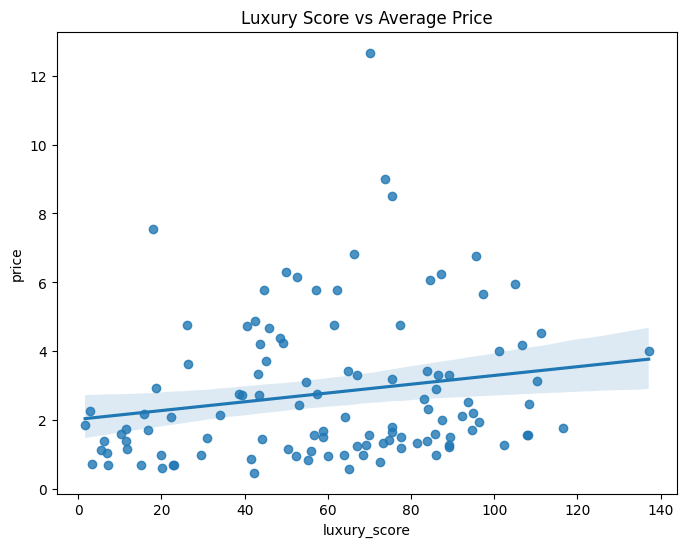

In [32]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=temp,
    x='luxury_score',
    y='price'
)

plt.title("Luxury Score vs Average Price")

~ I plotted a graph of how price changes as luxury score increases. I am proud of myself.

### price analysis

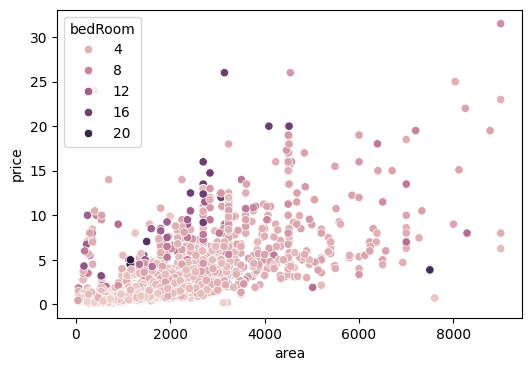

In [33]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df[df['area']<10000],
    x='area',
    y='price',
    hue='bedRoom'
)
plt.show()

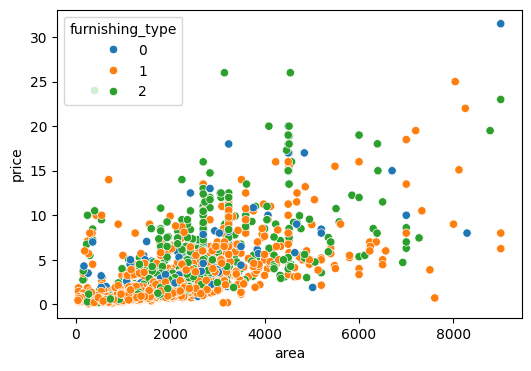

In [35]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df[df['area'] < 10000]['area'],
    y=df[df['area'] < 10000]['price'],
    hue=df[df['area'] < 10000]['furnishing_type'].astype('category')
)

plt.show()

<Axes: xlabel='bedRoom', ylabel='price'>

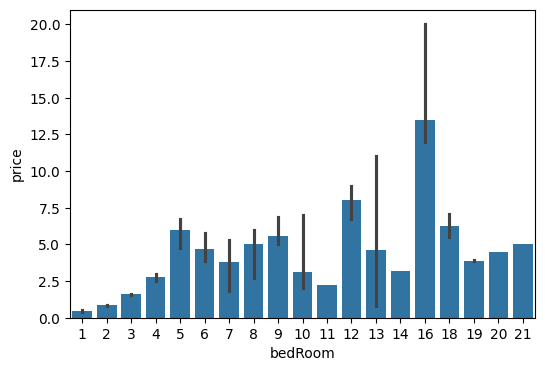

In [37]:
plt.figure(figsize=(6,4))
sns.barplot(x=df['bedRoom'],y=df['price'],estimator=np.median)

~ For some weird insight,mean cost of 16 bedroom house is more that that of housesmore that 16 bedrooms. Maybe it has better luxury score or something?

In [40]:
df[df['bedRoom']==16].sample(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,AC,Washing Machine,Dining Table,Microwave,Wardrobe,Bed,Modular Kitchen,Water Purifier,Exhaust Fan,Fan,Chimney,Stove,Sofa,Fridge,Light,Curtains,TV,Geyser,furnishing_type,luxury_score
3038,house,independent,sector 28,NaN,NaN,NaN,Plot area 270(225.75 sq.m.),16,16,3+,4.0,North-West,New Property,NaN,270.0,NaN,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,41
3698,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,0,0,0,0,8,0,1,0,1,9,1,1,0,0,16,0,0,3,2,49
372,house,independent,sector 11,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,Relatively New,NaN,1800.0,NaN,0,0,0,0,0,8,0,0,0,24,0,1,0,1,20,4,0,0,0,28,8,0,14,2,20


In [43]:
df.groupby('bedRoom')['luxury_score'].mean().sort_values(ascending=False).head(5)

bedRoom
3     81.740642
4     80.190909
19    71.000000
16    68.166667
9     64.707317
Name: luxury_score, dtype: float64

~ The reasoning is still not understood

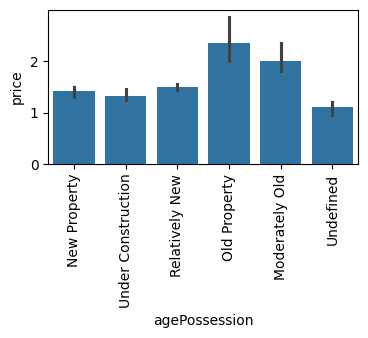

In [46]:
plt.figure(figsize=(4,2))
sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='furnishing_type', ylabel='price'>

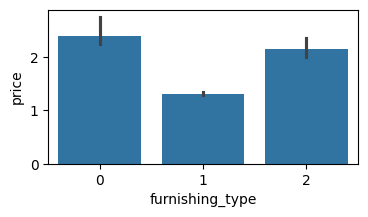

In [47]:
plt.figure(figsize=(4,2))
sns.barplot(x=df['furnishing_type'],y=df['price'],estimator=np.median)

- 1 > 2 > 0 
- (Unfurnished > Semi-furnished > Furnished)

## Total Correlation

<Axes: >

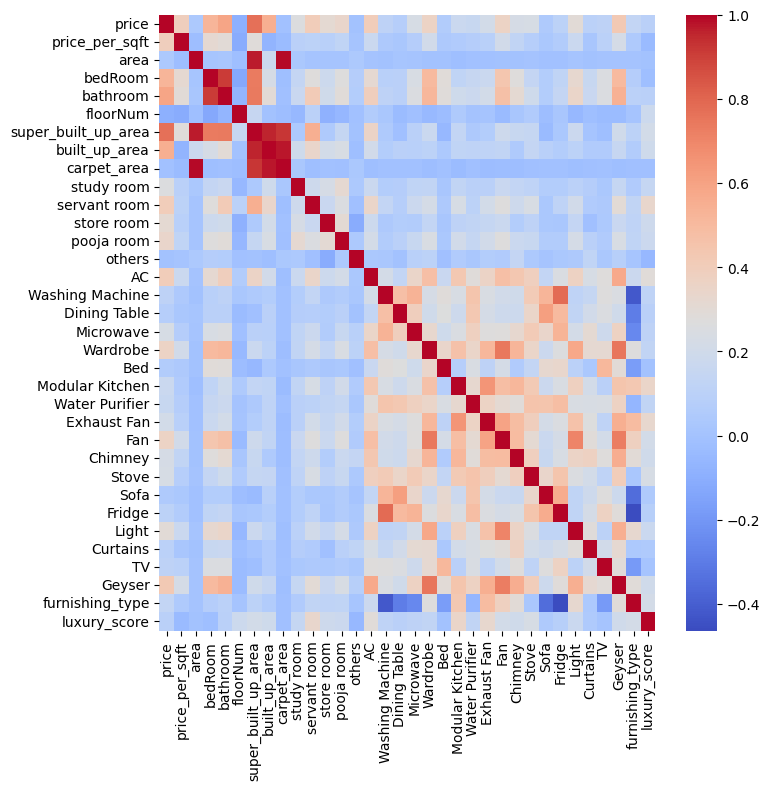

In [50]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')

In [54]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False).head(10)

price                  1.000000
super_built_up_area    0.769412
bathroom               0.589826
built_up_area          0.551649
bedRoom                0.522925
Geyser                 0.425640
AC                     0.404466
servant room           0.400927
price_per_sqft         0.391251
Fan                    0.361942
Name: price, dtype: float64

In [55]:
sns.pairplot(df)